# Riemann Sphere: Complete Visualization Guide

**Prerequisites**: Notebooks #1, #3 | **Time**: ~30 min

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp

try:
    import pyvista as pv
    HAS_PYVISTA = True
except ImportError:
    HAS_PYVISTA = False

def f(z):
    return (z - 1) / (z**2 + z + 1)

cmap = cp.Phase(phase_sectors=6, auto_scale_r=True)

## Mathematical Background

**Extended complex plane**: ℂ ∪ {∞}

**Stereographic projection** maps complex plane to sphere:
- Point at infinity → North pole  
- Origin → South pole
- Unit circle → Equator

## 2D Hemisphere Charts (matplotlib)

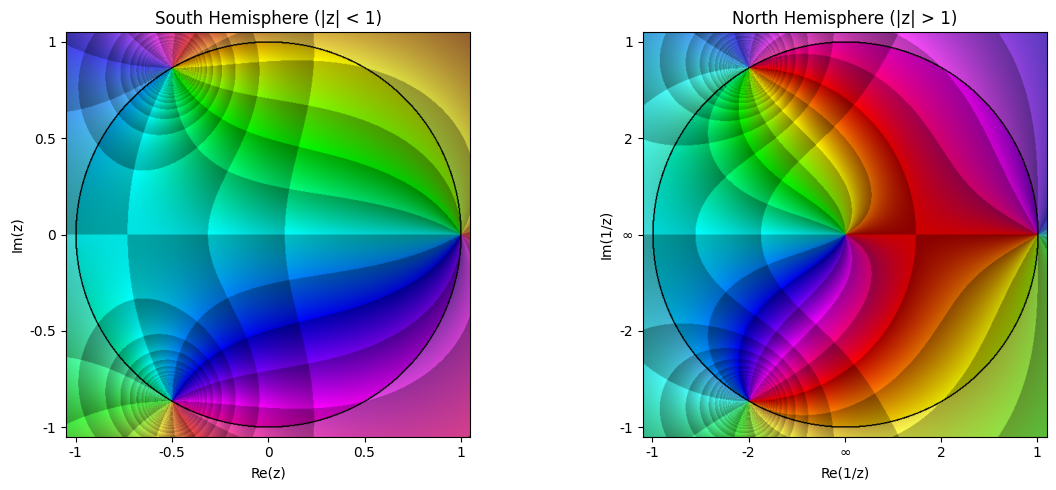


✓ Unit circle is the boundary between hemispheres


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# South hemisphere (|z| < 1)
cp.riemann_chart(f, show_south_hemisphere=True, ax=ax1, resolution=600)
ax1.set_title("South Hemisphere (|z| < 1)", fontsize=12)

# North hemisphere (|z| > 1, shown as 1/z)
cp.riemann_chart(f, show_south_hemisphere=False, ax=ax2, resolution=600)
ax2.set_title("North Hemisphere (|z| > 1)", fontsize=12)

plt.tight_layout()
plt.show()

print("\n✓ Unit circle is the boundary between hemispheres")

## 3D Sphere with PyVista

c:\Repos\complexplorer\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


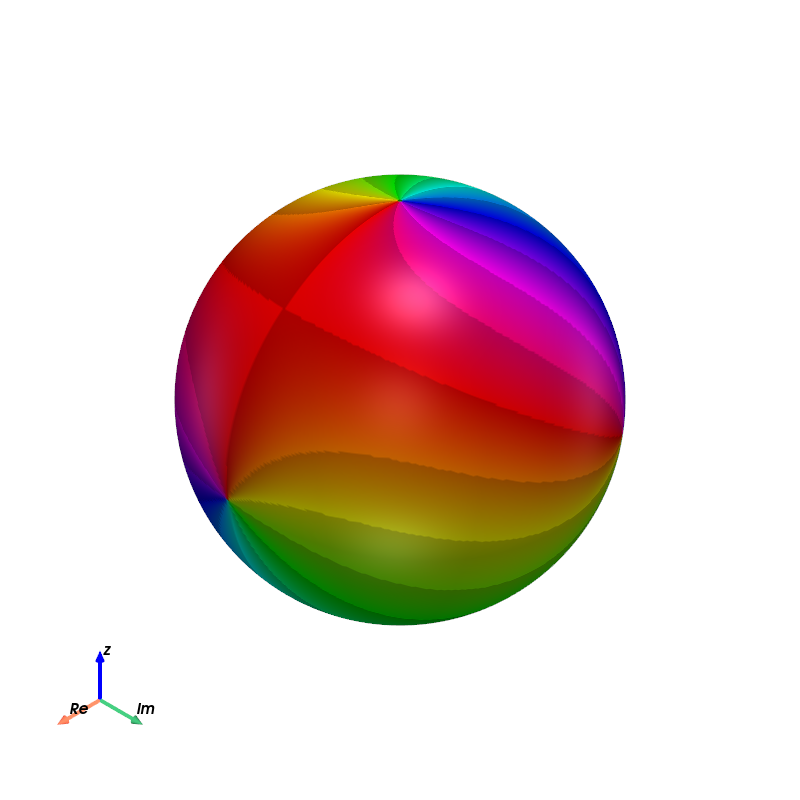


✓ Riemann sphere rendered inline
   For high quality: use notebook=False in standalone script


In [10]:
if HAS_PYVISTA:
    # Inline mode for notebook (use notebook=False for quality)
    cp.riemann_pv(
        f,
        resolution=400,
        modulus_mode='constant',  # Flat - phase only (see Notebook #7 for scaling)
        notebook=True,
        show=True
    )
    print("\n✓ Riemann sphere rendered inline")
    print("   For high quality: use notebook=False in standalone script")
else:
    # Fallback to matplotlib 3D
    cp.riemann(f, resolution=80, cmap=cmap)
    plt.show()
    print("\n✓ matplotlib 3D (install PyVista for better quality)")

## Functions with Interesting Behavior

### Essential Singularity: exp(1/z)

Wild behavior at origin → ∞ on sphere

c:\Repos\complexplorer\.venv\Lib\site-packages\matplotlib\colors.py:3175: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)
c:\Repos\complexplorer\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


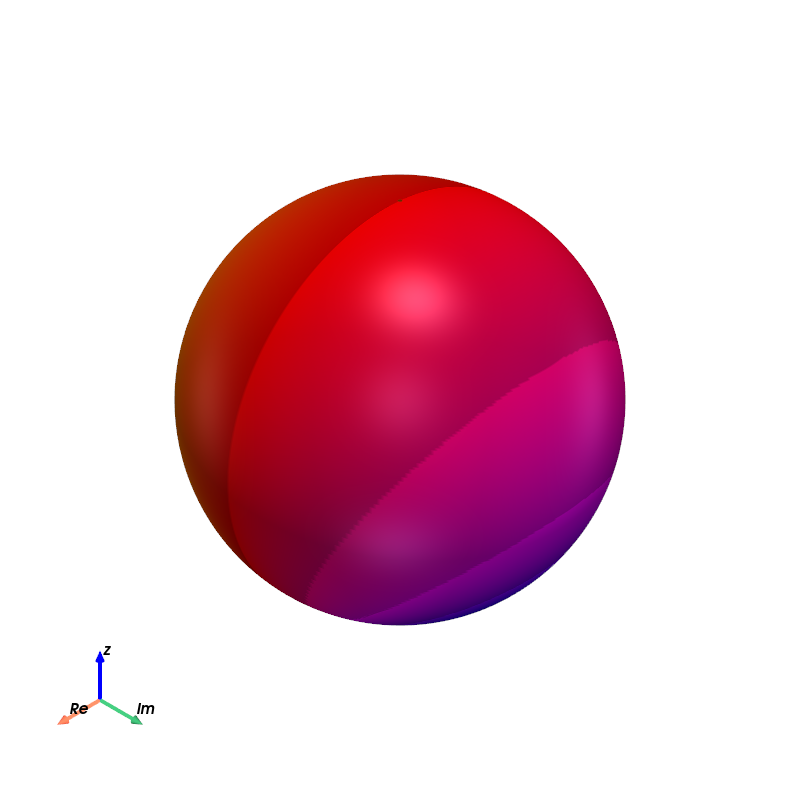


Essential singularity creates dense wrapping near origin!


In [11]:
def essential_sing(z):
    # Avoid exact zero
    return np.where(np.abs(z) > 0.01, np.exp(1/z), np.nan)

if HAS_PYVISTA:
    cp.riemann_pv(essential_sing, resolution=400, notebook=True, show=True)
    print("\nEssential singularity creates dense wrapping near origin!")

## Modulus Scaling Preview

Flat (constant height) vs scaled:

```python
# Phase only (flat)
cp.riemann_pv(f, modulus_mode='constant', notebook=True)

# With modulus scaling (topographic)
cp.riemann_pv(f, modulus_mode='arctan', notebook=True)
```

See **Notebook #7** for full modulus scaling guide!

## Summary

✅ Extended plane: ℂ ∪ {∞}
✅ Stereographic projection  
✅ 2D hemisphere charts
✅ 3D sphere (PyVista)
✅ Essential singularities

**Next**: Notebook #7 (Modulus Scaling)

See [Riemann Guide](../../docs/user-guide/riemann.md)